In [1]:
from langgraph.graph import StateGraph, START , END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
class CrashState(TypedDict):

    input: str
    step1: str
    step2: str
    step3: str

In [4]:
def step_1(state: CrashState):

    print(" Step 1 executed")
    return {'step1':'done', "input": state['input']}

def step_2(state: CrashState):
    print(" Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)
    return {"step2":"done"}

def step_3(state: CrashState):
    print("Step 3 executed")
    return {"step3":"done"}

In [5]:
graph = StateGraph(CrashState)

graph.add_node('step_1',step_1)
graph.add_node('step_2',step_2)
graph.add_node('step_3',step_3)


graph.add_edge(START, 'step_1')
graph.add_edge('step_1', 'step_2')
graph.add_edge('step_2', 'step_3')
graph.add_edge('step_3', END)

check_pointer = InMemorySaver()

workflow = graph.compile(checkpointer=check_pointer)

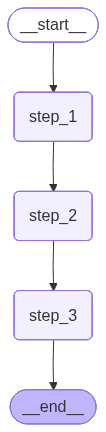

In [6]:
workflow

In [10]:
config = {'configurable':{"thread_id":'1'}}
try:
    workflow.invoke({'input':'my name is saeed'}, config=config)
except KeyboardInterrupt:
    print(" Kernel manually interrupted (crash simulated).")

 Step 1 executed
 Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
 Kernel manually interrupted (crash simulated).


In [11]:
workflow.get_state({"configurable":{"thread_id":'1'}})

StateSnapshot(values={'input': 'my name is saeed', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=('step_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1761e2-3355-692d-8006-d881156719e9'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-07-02T13:58:43.699107+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1761e2-3352-60f6-8005-5e719dbdbfd2'}}, tasks=(PregelTask(id='f9acded1-c6c9-27ff-7160-7297be0db5cc', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [12]:
list(workflow.get_state_history({"configurable":{"thread_id":'1'}}))

[StateSnapshot(values={'input': 'my name is saeed', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=('step_2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1761e2-3355-692d-8006-d881156719e9'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-07-02T13:58:43.699107+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1761e2-3352-60f6-8005-5e719dbdbfd2'}}, tasks=(PregelTask(id='f9acded1-c6c9-27ff-7160-7297be0db5cc', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'my name is saeed', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=('step_1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1761e2-3352-60f6-8005-5e719dbdbfd2'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-07-02T13:58:43.697666+00: